In [1]:
import pandas as pd
import random
import numpy as np

np.random.seed(1234)
random.seed(1234)


In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')


In [4]:
df[['Embarked', 'Survived', 'PassengerId']].dropna().groupby(['Embarked', 'Survived'])[['PassengerId']].count()

PassengerId
Embarked Survived             
C        0                  75
         1                  93
Q        0                  47
         1                  30
S        0                 427
         1                 217

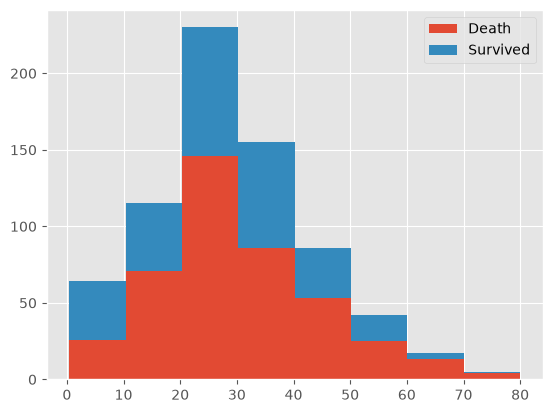

In [5]:
plt.hist(x = [df.Age[df.Survived == 0 ], df.Age[df.Survived==1]], 
            bins = 8, histtype='barstacked', label=['Death', 'Survived'])
plt.legend()


<Axes: xlabel='Pclass'>

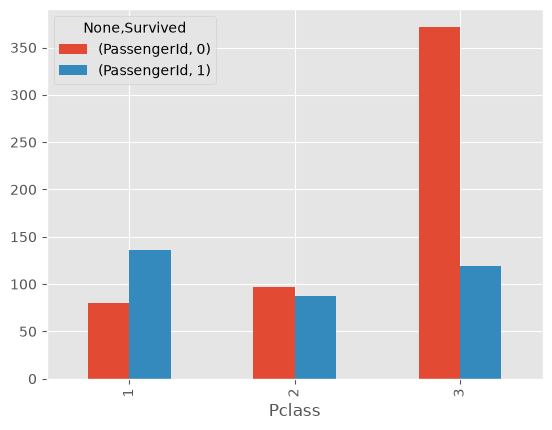

In [6]:
df[['Pclass', 'Survived', 'PassengerId']].dropna().groupby(['Pclass', 'Survived']).count().unstack().plot.bar()

In [7]:
import random
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [8]:
class RetryState(TypedDict):
    data: str
    attempts: int
    result: str


In [9]:
def process_node(state: RetryState) -> dict:
    current_attempt = state.get("attempts", 0) + 1
    # 30% 확률로 성공 모사
    if random.random() < 0.3:
        return {"result": "성공", "attempts": current_attempt}
    return {"attempts": current_attempt}

def retry_router(state: RetryState) -> str:
    if state.get("result"):
        return "success"
    if state["attempts"] < 3:
        return "retry"
    return "fatal_fail"

def fail_node(state: RetryState) -> dict:
    return {"result": f"최종 실패 ({state['attempts']}회 시도 초과)"}


In [10]:
builder = StateGraph(RetryState)
builder.add_node("process", process_node)
builder.add_node("fail", fail_node)

builder.add_edge(START, "process")
builder.add_conditional_edges(
    "process",
    retry_router,
    {
        "retry": "process",
        "success": END,
        "fatal_fail": "fail"
    }
)
builder.add_edge("fail", END)
graph = builder.compile()


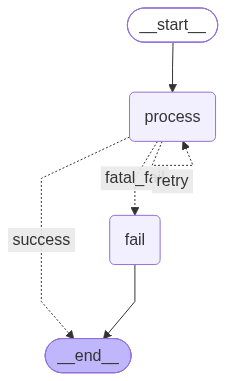

In [12]:
graph

In [11]:
graph.invoke({})

{'attempts': 2, 'result': '성공'}

In [13]:
import operator
from typing import TypedDict, Annotated, List, Dict, Any
from langgraph.graph import StateGraph, START, END


In [14]:
# 1. State 및 Reducer 정의
class DistributedCollectorState(TypedDict):
    query: str
    # 리스트 누적 Reducer[cite: 2]
    results: Annotated[List[str], operator.add]
    # Dict 병합 커스텀 Reducer[cite: 2]
    telemetry_stats: Annotated[Dict[str, Any], lambda old, new: {**old, **new}]


In [15]:
# 2. 병렬 실행 워커 노드 정의 (Delta 리턴 원칙 준수)[cite: 2]
def fetch_web_node(state: DistributedCollectorState) -> dict:
    return {
        "results": [f"Web Result: {state['query']}"],
        "telemetry_stats": {"web_latency_ms": 120}
    }

def fetch_db_node(state: DistributedCollectorState) -> dict:
    return {
        "results": [f"DB Record: {state['query']}"],
        "telemetry_stats": {"db_status": "ok"}
    }

def fetch_cache_node(state: DistributedCollectorState) -> dict:
    return {
        "results": [f"Cache Snapshot: {state['query']}"],
        "telemetry_stats": {"cache_hit": True}
    }


In [16]:
# 3. 수렴 노드 (Fan-In / Sink Node) 정의[cite: 2]
def compile_report_node(state: DistributedCollectorState) -> dict:
    # 모든 병렬 수집 결과가 Reducer에 의해 완전히 병합된 후 실행됨[cite: 2]
    print(f"[Sink Node] 수집 완료. 총 {len(state['results'])}개 출처 수렴됨.")
    return {}


In [17]:
# 4. 그래프 구조 작성
builder = StateGraph(DistributedCollectorState)

builder.add_node("web_worker", fetch_web_node)
builder.add_node("db_worker", fetch_db_node)
builder.add_node("cache_worker", fetch_cache_node)
builder.add_node("sink_reporter", compile_report_node)

# START -> Fan-Out (병렬 분기)[cite: 2]
builder.add_edge(START, "web_worker")
builder.add_edge(START, "db_worker")
builder.add_edge(START, "cache_worker")

# Fan-In -> 수렴 노드로 연결[cite: 2]
builder.add_edge("web_worker", "sink_reporter")
builder.add_edge("db_worker", "sink_reporter")
builder.add_edge("cache_worker", "sink_reporter")

builder.add_edge("sink_reporter", END)

graph = builder.compile()


In [18]:
# 5. 실행
if __name__ == "__main__":
    init_state = {"query": "LangGraph Parallel", "results": [], "telemetry_stats": {}}
    output = graph.invoke(init_state)
    
    print("\n--- [최종 누적 결과] ---")
    print(output["results"])
    print("\n--- [병합 메타데이터] ---")
    print(output["telemetry_stats"])


[Sink Node] 수집 완료. 총 3개 출처 수렴됨.

--- [최종 누적 결과] ---
['Cache Snapshot: LangGraph Parallel', 'DB Record: LangGraph Parallel', 'Web Result: LangGraph Parallel']

--- [병합 메타데이터] ---
{'cache_hit': True, 'db_status': 'ok', 'web_latency_ms': 120}


In [19]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


In [20]:
# 1. 챗봇 노드 함수 정의
def echo_bot(state: MessagesState) -> dict:
    messages = state["messages"]
    if not messages:
        return {"messages": []}
    
    last_msg = messages[-1]
    content = last_msg.content if hasattr(last_msg, "content") else last_msg.get("content", "")
    
    ai_message = {
        "role": "ai",
        "content": f"기억된 대화 응답: {content}"
    }
    return {"messages": [ai_message]}


In [21]:
# 2. 그래프 작성 및 MemorySaver 전달 컴파일
builder = StateGraph(MessagesState)
builder.add_node("bot", echo_bot)
builder.add_edge(START, "bot")
builder.add_edge("bot", END)

# compile에 checkpointer를 주입합니다.
graph = builder.compile(checkpointer=MemorySaver())


In [22]:
# 3. 세션 식별용 config 지정
config = {
    "configurable": {
        "thread_id": "session-1"
    }
}


In [23]:
# 4. 동일 thread_id로 연속 호출 (이전 메시지가 누적됨)
graph.invoke({"messages": [{"role": "user", "content": "내 이름은 홍길동이야."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "내 이름이 뭐라고 했지?"}]}, config)


{'messages': [HumanMessage(content='내 이름은 홍길동이야.', additional_kwargs={}, response_metadata={}, id='8a15bdcd-7e2c-41a4-a3bf-3f70735a1012'),
  AIMessage(content='기억된 대화 응답: 내 이름은 홍길동이야.', additional_kwargs={}, response_metadata={}, id='d14cfba4-4a54-40af-ae66-065f4747a45d', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='내 이름이 뭐라고 했지?', additional_kwargs={}, response_metadata={}, id='26719afa-c933-41e0-90bd-23f527e5a8eb'),
  AIMessage(content='기억된 대화 응답: 내 이름이 뭐라고 했지?', additional_kwargs={}, response_metadata={}, id='b784668b-dcba-4f9d-8705-ffe3ccdff345', tool_calls=[], invalid_tool_calls=[])]}

In [24]:
# 5. 저장된 최종 상태 조회
saved_state = graph.get_state(config)
print(f"누적 메시지 수: {len(saved_state.values['messages'])}개")


누적 메시지 수: 4개


In [25]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain.tools import tool
import os
import pandas as pd 
import io 
import requests 
from langgraph.prebuilt import create_react_agent


In [26]:
llm = ChatOllama(
   base_url="http://host.docker.internal:11434", # 원격 서버 주소
   model="gemma4:31b-mlx",
   temperature=0.2,
   reasoning=True
)
